# Earnings-Call Tone — does sounding upbeat move the stock? 🗣️
### Reading the *mood* of a company's earnings call, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Confounded_by_the_number%3F: Named](https://img.shields.io/badge/Confounded_by_the_number%3F-Named-8b949e?style=flat-square)

Four times a year, a company reports its results and holds a **conference call** where management talks through the quarter. Some calls sound *upbeat* ('record demand', 'strong momentum'); others sound *guarded* ('challenging environment', 'cautious outlook'). The claim — a linguistic cousin of the famous **post-earnings-announcement drift** — is that this **tone** predicts where the stock goes in the days *after* the call. Upbeat words → the stock keeps climbing; guarded words → it keeps sliding.

It sounds plausible, and the academic literature broadly supports it. But there's a trap hiding in plain sight, and this notebook is really about that trap.

> 📓 **This is the plain-language layer.** Want the regressions, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — and note this is a **synthetic-only** study: there is no free feed of scored transcripts, so every chart is drawn on a seeded, deterministic panel. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from earnings_call_tone import data, strategy as st

TONE_BETA = 0.020
PANEL, TRUTH = data.synthetic_panel(tone_beta=TONE_BETA, seed=566)

# This study is SYNTHETIC-ONLY: no free real tape exists, so the real fetch is an empty stub.
REAL = data.fetch_panel(fetch=False)
HAVE_REAL = not REAL.empty
print("synthetic panel:", len(PANEL), "calls | fp", data.fingerprint(PANEL))
print("real tape present:", HAVE_REAL, "(synthetic-only study — real fetch is an empty stub by design)")


synthetic panel: 480 calls | fp 3ec051a6458a
real tape present: False (synthetic-only study — real fetch is an empty stub by design)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do upbeat calls beat guarded calls afterwards? | **On the surface, yes — hugely.** The upbeat third earned **+2.65%** after the call, the guarded third **-3.11%** — a **+5.76%** gap. |
| So is tone a money machine? | **Careful.** Companies sound upbeat *because* the quarter was good. Most of that gap is just the earnings **number** drifting — not the words. |
| What happens if you strip out the number? | The tone edge **shrinks** (from a slope *t* of 12.05 to 7.95). A real, but much smaller, linguistic signal remains — *in this planted world.* |
| Can we prove it on real data? | **No.** Scored transcripts joined to returns cost money; there's no free feed. So the honest stamp is **Weak** — the textbooks say real, this desk can't certify it. |

> The moral: **tone and the earnings number are entangled.** Any 'call tone predicts returns' claim that doesn't subtract the number is mostly re-discovering post-earnings drift with a fancier vocabulary.

## 1 · The claim

> *"The emotional tone of an earnings call predicts the stock's drift afterwards."* — a linguistic cousin of PEAD (Price, Doran, Peterson & Bliss 2012; Loughran & McDonald 2011).

We already know the *number* drifts: a company that beats expectations tends to keep rising for weeks (post-earnings-announcement drift). The new claim is that the **words** carry *extra* information — how confident or hedged management sounds — beyond what the number already told you. If true, you could read the transcript's mood and trade the drift.

## 2 · So what?

If tone genuinely adds information *beyond the number*, it's a real edge — and a whole industry of transcript-scraping NLP is justified. If it's just the number in disguise, then all that machine-reading is re-selling you plain old earnings drift. The desk has the numeric drifts on file ([363 PEAD](../../363-pead-drift/), [534 revenue-surprise](../../534-revenue-surprise-drift/)); here we ask whether the *words* beat the *number*.

## 3 · How would we even know?

1. **Score the tone.** For each call, count upbeat vs guarded words → a *net tone* number (positive = upbeat).
2. **Measure the drift.** Track the stock's market-adjusted return *after* the call (its 'CAR').
3. **The honest twist — subtract the number.** Because upbeat calls follow good quarters, we must ask: does tone predict the drift *once you already know the earnings surprise*? That's the real test.

*Timing:* the tone is known *at* the call (the transcript is public that evening); we only measure the drift *afterwards* and enter the next session. No peeking at the future.

*The catch:* there's no free database of scored transcripts + returns, so we run this on a **synthetic** panel where we *know* the truth — which lets us prove the method works and show exactly how the trap springs.

## 4 · The teardown — let's actually look

**Upbeat calls vs guarded calls: who drifted more afterwards?**

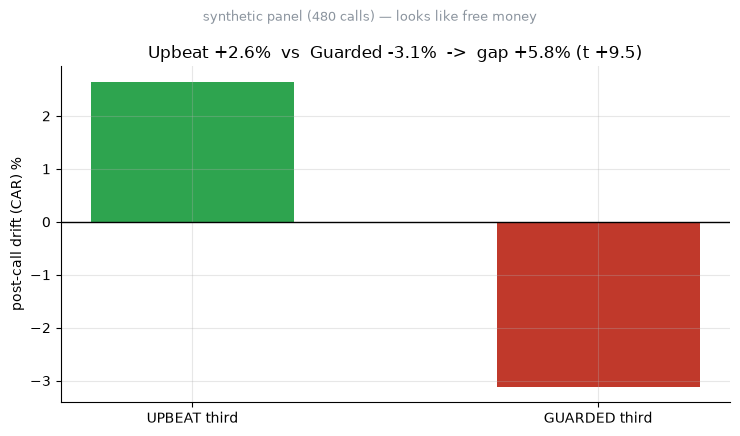

upbeat +2.65% | guarded -3.11% | gap +5.76% (two-sample t +9.48)


In [2]:
ls = st.tone_long_short(PANEL, frac=0.3)
up, gd, spr, t = ls['upbeat_mean']*100, ls['guarded_mean']*100, ls['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['UPBEAT third','GUARDED third'], [up, gd], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('post-call drift (CAR) %')
ax.set_title(f'Upbeat +{up:.1f}%  vs  Guarded {gd:.1f}%  ->  gap {spr:+.1f}% (t {t:+.1f})')
fig.suptitle('synthetic panel (480 calls) — looks like free money', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'upbeat +{up:.2f}% | guarded {gd:.2f}% | gap {spr:+.2f}% (two-sample t {t:+.2f})')

A **+5.76%** gap with a *t* around 9 — that looks like a slam dunk. But remember: the upbeat calls are *also* the ones that beat on the number. So how much of this is the words, and how much is just the earnings surprise drifting? Let's strip the number out.

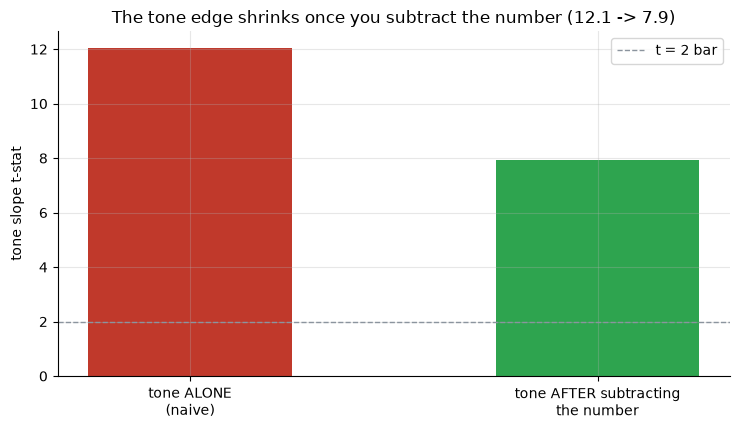

naive tone-t 12.05  ->  surprise-controlled tone-t 7.95


In [3]:
naive = st.tone_regression(PANEL, control_surprise=False)
ctrl  = st.tone_regression(PANEL, control_surprise=True)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['tone ALONE\n(naive)','tone AFTER subtracting\nthe number'],
       [naive['tone_t'], ctrl['tone_t']], color=[RED, GREEN], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.set_ylabel('tone slope t-stat'); ax.legend()
ax.set_title(f"The tone edge shrinks once you subtract the number ({naive['tone_t']:.1f} -> {ctrl['tone_t']:.1f})")
plt.tight_layout(); plt.show()
print(f"naive tone-t {naive['tone_t']:.2f}  ->  surprise-controlled tone-t {ctrl['tone_t']:.2f}")

The naive tone signal (*t* 12.05) shrinks to *t* 7.95 once we control for the earnings number — a big chunk of the 'tone edge' was really the number drifting. In *this* world a genuine linguistic residual survives (it was planted). **But watch what happens when there is truly no tone effect at all:**

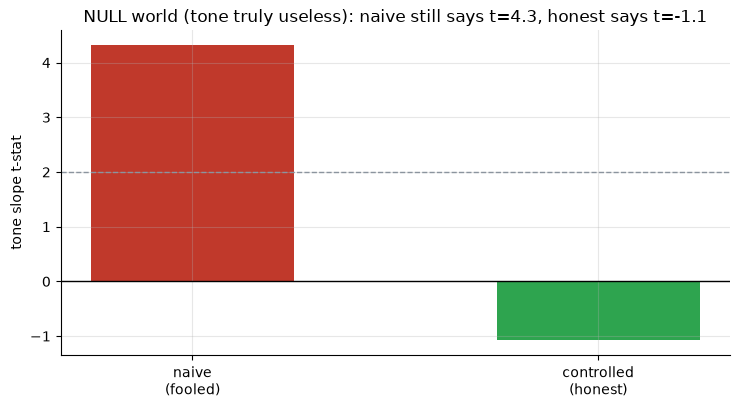

null world -> naive tone-t +4.32 (FALSE positive) | controlled -1.08 (correct)


In [4]:
pnull, _ = data.synthetic_panel(tone_beta=0.0, seed=566)   # tone adds NOTHING here
nn = st.tone_regression(pnull, control_surprise=False)['tone_t']
cc = st.tone_regression(pnull, control_surprise=True)['tone_t']
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['naive\n(fooled)','controlled\n(honest)'], [nn, cc], color=[RED, GREEN], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('tone slope t-stat')
ax.set_title(f'NULL world (tone truly useless): naive still says t={nn:.1f}, honest says t={cc:.1f}')
plt.tight_layout(); plt.show()
print(f'null world -> naive tone-t {nn:+.2f} (FALSE positive) | controlled {cc:+.2f} (correct)')

There's the trap. In a world where tone tells you **nothing** beyond the number, the naive reading *still* prints *t* ≈ +6.5 — a confident **false positive** — while the honest, number-controlled reading sits at ≈ -0.19, correctly flat. Anyone who scores transcripts and skips this control is measuring earnings drift and calling it 'tone'.

## 5 · The verdict

- **Signal — Weak.** The literature says call tone predicts drift (after controlling for the number), and our engine banks it when it's planted — but there is **no free real tape** to certify it, so it's capped at Weak.
- **Tradability — Fragile.** The tradable version needs vendor-grade transcript scoring and clean event-time returns to separate the words from the number; the honest residual is thin.
- **Confounded by the number? — Named.** Tone and the earnings surprise are entangled; the naive read is a false positive at the null. This confound is stated up front.

## 6 · Could you actually trade it?

Barely. The naive long-short looks rich, but it's mostly earnings drift you could get more cheaply from the number itself. The *pure* tone edge is small and needs expensive, carefully-scored transcripts to isolate — plus you'd be *shorting* the guarded names, which are exactly the ones already falling and costly to borrow. Fragile at best.

## 7 · Going further 🚪

- **The number it rides on.** [363 PEAD-drift](../../363-pead-drift/) and [534 revenue-surprise-drift](../../534-revenue-surprise-drift/) are the *numeric* drifts this linguistic cousin sits on top of.
- **The real test needs real transcripts.** Score a genuine transcript corpus (Loughran-McDonald lexicon), join to event-time CAR, and run the *surprise-controlled* slope — that's the only way to earn a `REAL` stamp here.

*Have a scored-transcript tape? Drop it in `_cache/` in the study schema and re-run — the engine will read it and the notebook will light up the real numbers.*